In [77]:
print("Segmentation")

Segmentation


In [78]:
import copy
import numpy as np 

import torch
import torch.optim as optim 
import torch.nn as nn 
import torch.nn.functional as F 

import torchvision
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset,Subset
from torchvision import transforms
from torchvision.transforms import Compose, Normalize, Pad
from torchvision import models

import cv2
from PIL import Image
import pandas as pd

import matplotlib.pyplot as plt
from torchvision.ops import nms

from PIL import Image, ImageDraw, ImageFont

import os
import time

In [79]:
label_semantic_dataset_path = "/kaggle/input/datasets/santurini/semantic-segmentation-drone-dataset/classes_dataset/classes_dataset/label_images_semantic"
original_images_path = "/kaggle/input/datasets/santurini/semantic-segmentation-drone-dataset/classes_dataset/classes_dataset/original_images"

In [80]:
image_names = os.listdir(original_images_path)
semantic_names = os.listdir(label_semantic_dataset_path)

In [81]:
image_paths = []
semantic_paths = []
for img in os.listdir(original_images_path):
    if img in image_names:
        img_path = os.path.join(original_images_path,img)
        semantic_path = os.path.join(label_semantic_dataset_path,img)
        image_paths.append(img_path)
        semantic_paths.append(semantic_path)

In [82]:
print(len(image_paths))
print(len(semantic_paths))

400
400


In [83]:
print(image_paths[0])
print("##########################")
print(semantic_paths[0])

/kaggle/input/datasets/santurini/semantic-segmentation-drone-dataset/classes_dataset/classes_dataset/original_images/173.png
##########################
/kaggle/input/datasets/santurini/semantic-segmentation-drone-dataset/classes_dataset/classes_dataset/label_images_semantic/173.png


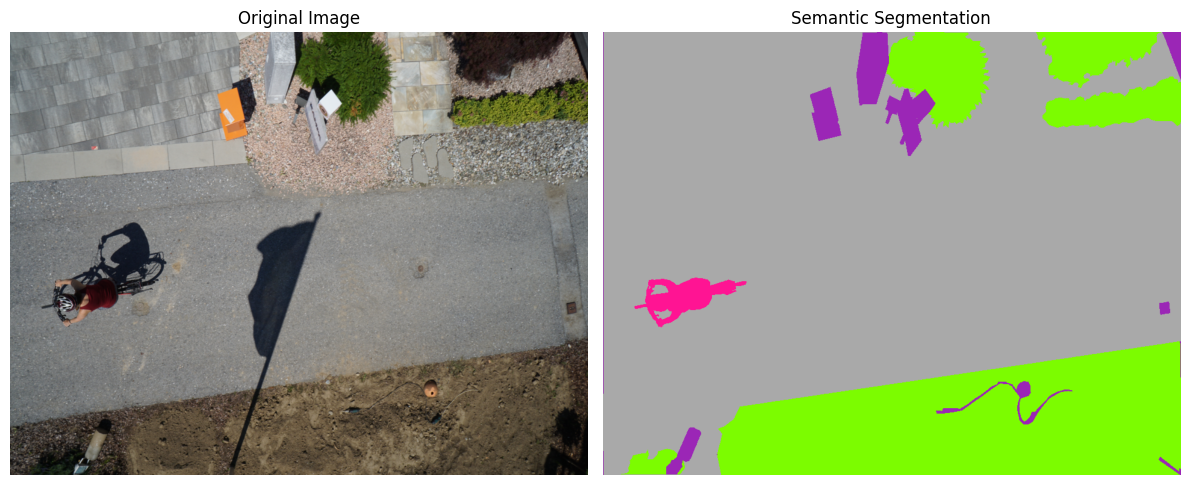

In [84]:
import cv2
import matplotlib.pyplot as plt


image = cv2.imread(image_paths[68])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

semantic = cv2.imread(semantic_paths[68])


semantic = cv2.cvtColor(semantic, cv2.COLOR_BGR2RGB)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(semantic)
axes[1].set_title("Semantic Segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [85]:
semantic_rgb = cv2.cvtColor(
    cv2.imread(semantic_paths[0]),
    cv2.COLOR_BGR2RGB
)

print("Shape:", semantic_rgb.shape)
print("Unique colors:", np.unique(semantic_rgb.reshape(-1, 3), axis=0))

Shape: (736, 960, 3)
Unique colors: [[ 14 135 204]
 [124 252   0]
 [155  38 182]
 [169 169 169]
 [255  20 147]]


In [86]:
class Semantic_dataset(Dataset):
    def __init__(self,image_paths,semantic_paths,transform=None):
        self.image_paths = image_paths
        self.semantic_paths = semantic_paths
        self.transform = transform
        self.color_to_class = {
             (155, 38, 182): 0,   # obstacles
            (14, 135, 204): 1,   # water
            (124, 252, 0): 2,    # nature
            (255, 20, 147): 3,   # moving
            (169, 169, 169): 4   # landable
        }
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self,index):
        image = self.image_paths[index]
        image = cv2.imread(image)
        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        image = cv2.resize(image,(224,224),interpolation=cv2.INTER_LINEAR)

        image = torch.tensor(image,dtype=torch.float32)

        image = image.permute(2,0,1)
        image = image / 255.0

        if self.transform is not None:
            image = self.transform(image)


        semantic = self.semantic_paths[index]
        semantic = cv2.imread(semantic)
        semantic = cv2.cvtColor(semantic,cv2.COLOR_BGR2RGB)
        semantic = cv2.resize(semantic,(224,224),interpolation=cv2.INTER_NEAREST)

        mask = np.zeros(semantic.shape[:2],dtype=np.int64)
        for clr,cls_id in self.color_to_class.items():
            mask[np.all(semantic==clr,axis=-1)] = cls_id
        mask = torch.tensor(mask,dtype=torch.long)
        return image,mask
        

In [87]:
transform = transforms.Compose([
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [88]:
ds = Semantic_dataset(image_paths,semantic_paths,transform)

In [89]:
print(len(ds))

400


In [90]:
def index_splitter(number,amount):
    indices = np.arange(number)
    amount = torch.tensor(amount)
    amount = amount * number
    amount = amount / 100
    amount = amount.int()
    amount[0] += (number-amount.sum())
    split1, split2,split3 = random_split(indices,amount)
    return split1.indices,split2.indices,split3.indices

In [91]:
train_indices,test_indices,val_indices = index_splitter(len(ds),[88,7,5])

In [92]:
train_set = Subset(ds,train_indices)
test_set = Subset(ds,test_indices)
val_set = Subset(ds,val_indices)

In [93]:
print(len(train_set))
print(len(test_set))
print(len(val_set))

352
28
20


In [94]:
train_loader = DataLoader(train_set,batch_size=32,shuffle=True)
val_loader = DataLoader(val_set,batch_size=32)
test_loader = DataLoader(test_set,batch_size=32)

In [95]:
for img,msk in train_loader:
    print(img.shape)
    print(msk.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32, 224, 224])


In [96]:
class DoubleConv(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self,x):
        return self.block(x)
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(3,64)
        self.enc2 = DoubleConv(64,128)
        self.enc3 = DoubleConv(128,256)
        self.enc4 = DoubleConv(256,512)

        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)

        self.bottleneck = DoubleConv(512,1024)


        self.up4 = nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2)
        self.dec4 = DoubleConv(1024,512)

        self.up3 = nn.ConvTranspose2d(512,256,kernel_size=2,stride=2)
        self.dec3 = DoubleConv(512,256)

        self.up2= nn.ConvTranspose2d(256,128,kernel_size=2,stride=2)
        self.dec2 = DoubleConv(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,kernel_size=2,stride=2)
        self.dec1 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,5,kernel_size=1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4,e4],dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3,e3],dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2,e2],dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1,e1],dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [97]:
class DeepLearner:
    def __init__(self,model,loss_fn,optimizer):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.best_model_weights = None
        self.best_val_loss = float("inf")
        self.last_optimizer_state = None
        self.last_model_weights = None
        self.train_losses = []
        self.val_losses = []
        self.epoch = 0
        self.test_loader = None
        self.train_loader = None
        self.val_loader = None
    def set_loaders(self,train_loader=None,val_loader=None,test_loader=None):
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader
    def train_each_batch(self):
        self.model.train()
        total_loss = 0.0
        for images,masks in self.train_loader:
            images = images.to(self.device)
            masks = masks.to(self.device)
            self.optimizer.zero_grad()
            pred_masks = self.model(images)
            train_loss = self.loss_fn(pred_masks,masks)
            total_loss += train_loss.item()
            train_loss.backward()
            self.optimizer.step()
        total_loss = total_loss/len(self.train_loader)
        return total_loss
    def validate_each_batch(self):
        self.model.eval()
        total_loss = 0.0
        for images,masks in self.val_loader:
            images = images.to(self.device)
            masks = masks.to(self.device)
            pred_masks = self.model(images)
            val_loss = self.loss_fn(pred_masks,masks)
            total_loss += val_loss.item()
        total_loss = total_loss/len(self.val_loader)
        return total_loss
    def pick_the_best_model(self):
        self.model.load_state_dict(self.best_model_weights)
    def plot(self,starting_index):
        epochs = range(starting_index+1, len(self.train_losses) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.train_losses[starting_index:], marker="o", label="Training Loss")
        plt.plot(epochs, self.val_losses[starting_index:], marker="o", label="Validation Loss")


        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.xticks(epochs)
        plt.legend()
        plt.grid(True)

        plt.show()
    def train(self,n_epochs):
        if self.epoch!=0:
            self.model.load_state_dict(self.last_model_weights)
            self.optimizer.load_state_dict(self.last_optimizer_state)
        initial_epoch = self.epoch
        print("Device:",self.device)
        while self.epoch + 1 <= initial_epoch + n_epochs:
            starting_time = time.time()
            self.epoch  += 1 
            train_loss = self.train_each_batch()
            self.train_losses.append(train_loss)
            val_loss = self.validate_each_batch()
            self.val_losses.append(val_loss)
            print("Epoch:",self.epoch)
            gap = time.time()-starting_time
            mins = int(gap//60)
            seconds = int(gap-mins*60)
            second_string = "seconds"
            if seconds == 1:
                second_string = "second"
            print("Duration:",mins,"minutes and",seconds,second_string)
            print("Training Loss:",train_loss)
            print("Validation Loss:",val_loss)
            if val_loss<self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_model_weights = copy.deepcopy(self.model.state_dict())
                self.best_opt_state = copy.deepcopy(self.optimizer.state_dict())
                print("✅Best Model saved from epoch",self.epoch,"with validation loss",val_loss)
        self.last_model_weights = copy.deepcopy(self.model.state_dict())
        self.last_optimizer_state = copy.deepcopy(self.optimizer.state_dict())
        self.plot(initial_epoch)

In [98]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [99]:
def get_colored_predicted_mask(pred_mask,predicted_mask=True):
    if predicted_mask:
        class_id_indices = torch.argmax(pred_mask,dim=1)
    else:
        class_id_indices = pred_mask
    color_to_class = {
    (155, 38, 182): 0,   # obstacles
    (14, 135, 204): 1,   # water
    (124, 252, 0): 2,    # nature
    (255, 20, 147): 3,   # moving
    (169, 169, 169): 4   # landable
    }

    colored_mask = torch.zeros(class_id_indices.shape[0],class_id_indices.shape[1],class_id_indices.shape[2],3,dtype=torch.uint8)
    for color,class_id in color_to_class.items():
        colored_mask[class_id_indices == class_id] = torch.tensor(color,dtype=torch.uint8)
    return colored_mask

def plot_test_image_pred_mask(test_image,pred_mask):
    test_image = test_image.cpu()
    pred_mask = pred_mask[0].cpu()

    test_image = test_image.permute(1,2,0)
    mean = torch.tensor([0.485,0.456,0.406]).view(1,1,3)
    std = torch.tensor([0.229,0.224,0.225]).view(1,1,3)

    test_image = test_image * std + mean
    test_image = test_image.clamp(0,1)

    fig, axes = plt.subplots(1,2,figsize=(12,5))

    axes[0].imshow(test_image.numpy())
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(pred_mask.numpy())
    axes[1].set_title("Predicted Semantic Mask")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()



In [100]:
device

device(type='cuda')

In [101]:
_,mask = train_set[9]
unique,counts = torch.unique(mask,return_counts=True)
print(mask)
print("#########")
print(unique)
print("#########")
print(counts)
print(counts.tolist())

tensor([[2, 2, 2,  ..., 2, 2, 2],
        [2, 2, 2,  ..., 2, 2, 2],
        [2, 2, 2,  ..., 2, 2, 2],
        ...,
        [2, 0, 0,  ..., 2, 2, 2],
        [2, 0, 0,  ..., 2, 2, 2],
        [0, 0, 0,  ..., 2, 2, 2]])
#########
tensor([0, 2, 3, 4])
#########
tensor([ 2947, 28350,   300, 18579])
[2947, 28350, 300, 18579]


In [102]:
class_counts = [0]*5
total_pixels = 0
for i in range(0,len(train_set)):
    _,mask= train_set[i]
    unique, counts = torch.unique(mask,return_counts=True)
    unique =  unique.tolist()
    counts = counts.tolist()
    for i in range(0,len(unique)):
        class_counts[unique[i]] += counts[i]
        total_pixels = total_pixels + counts[i]
for i in range(len(class_counts)):
    class_counts[i] = class_counts[i]/total_pixels
    class_counts[i] *= 100
print(class_counts)

    

[9.013171364071198, 2.969683079197588, 34.02328915852563, 2.02708624731853, 51.96677015088705]


In [103]:
class_counts = torch.tensor(class_counts,dtype=torch.float32).to(device)
print(class_counts)
class_counts /=100.0
print(class_counts)

tensor([ 9.0132,  2.9697, 34.0233,  2.0271, 51.9668], device='cuda:0')
tensor([0.0901, 0.0297, 0.3402, 0.0203, 0.5197], device='cuda:0')


In [104]:
class_weights = 1.0 / torch.sqrt(class_counts)
class_weights = class_weights / class_weights.mean()

print(class_weights)

tensor([0.8648, 1.5065, 0.4451, 1.8235, 0.3601], device='cuda:0')


In [116]:
model = UNet()
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(),lr=1e-3)

In [117]:
dl = DeepLearner(model,loss_fn,optimizer)
dl.set_loaders(train_loader,val_loader,test_loader)

Device: cuda
Epoch: 1
Duration: 0 minutes and 21 seconds
Training Loss: 2.0773639137094673
Validation Loss: 1.5261555910110474
✅Best Model saved from epoch 1 with validation loss 1.5261555910110474
Epoch: 2
Duration: 0 minutes and 20 seconds
Training Loss: 1.4758501052856445
Validation Loss: 1.3203178644180298
✅Best Model saved from epoch 2 with validation loss 1.3203178644180298
Epoch: 3
Duration: 0 minutes and 20 seconds
Training Loss: 1.3674640438773416
Validation Loss: 1.2117137908935547
✅Best Model saved from epoch 3 with validation loss 1.2117137908935547
Epoch: 4
Duration: 0 minutes and 20 seconds
Training Loss: 1.1978935653513128
Validation Loss: 1.128331184387207
✅Best Model saved from epoch 4 with validation loss 1.128331184387207
Epoch: 5
Duration: 0 minutes and 20 seconds
Training Loss: 1.0904757976531982
Validation Loss: 1.012587547302246
✅Best Model saved from epoch 5 with validation loss 1.012587547302246
Epoch: 6
Duration: 0 minutes and 20 seconds
Training Loss: 0.96511

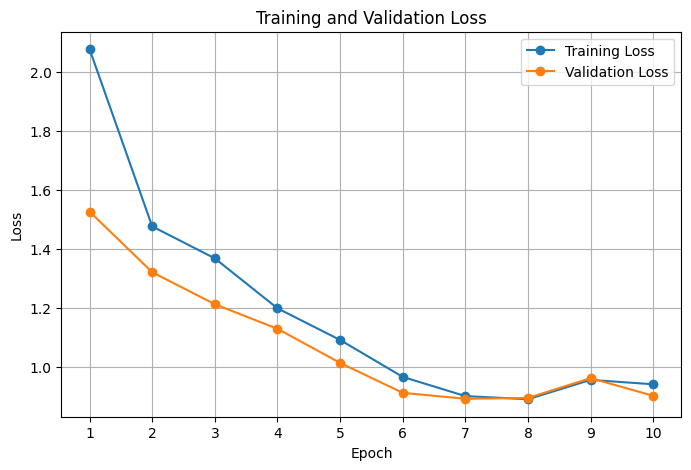

In [118]:
dl.train(10)

Device: cuda
Epoch: 11
Duration: 0 minutes and 21 seconds
Training Loss: 0.8849011822180315
Validation Loss: 0.8940402269363403
Epoch: 12
Duration: 0 minutes and 20 seconds
Training Loss: 0.8725972283970226
Validation Loss: 0.8517212271690369
✅Best Model saved from epoch 12 with validation loss 0.8517212271690369
Epoch: 13
Duration: 0 minutes and 20 seconds
Training Loss: 0.8346976150165905
Validation Loss: 0.8439745903015137
✅Best Model saved from epoch 13 with validation loss 0.8439745903015137
Epoch: 14
Duration: 0 minutes and 20 seconds
Training Loss: 0.8054035251790826
Validation Loss: 0.8361149430274963
✅Best Model saved from epoch 14 with validation loss 0.8361149430274963
Epoch: 15
Duration: 0 minutes and 20 seconds
Training Loss: 0.7989208427342501
Validation Loss: 0.8419358134269714
Epoch: 16
Duration: 0 minutes and 20 seconds
Training Loss: 0.7989184748042714
Validation Loss: 0.7941296100616455
✅Best Model saved from epoch 16 with validation loss 0.7941296100616455
Epoch: 17

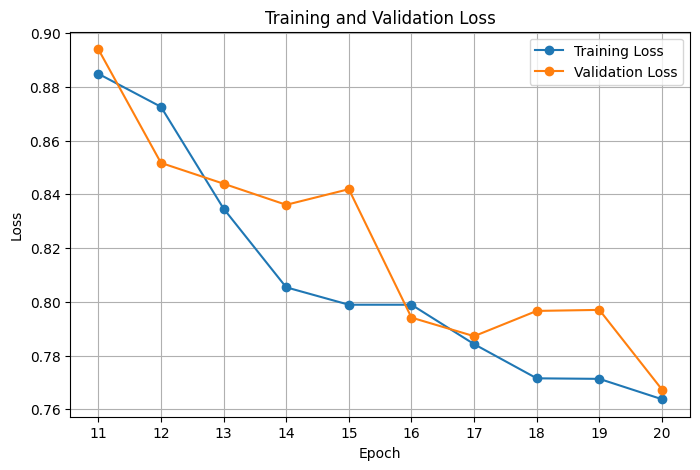

In [119]:
dl.train(10)

Device: cuda
Epoch: 21
Duration: 0 minutes and 20 seconds
Training Loss: 0.7565433166243813
Validation Loss: 0.7988303303718567
Epoch: 22
Duration: 0 minutes and 21 seconds
Training Loss: 0.7527814453298395
Validation Loss: 0.7548153400421143
✅Best Model saved from epoch 22 with validation loss 0.7548153400421143
Epoch: 23
Duration: 0 minutes and 20 seconds
Training Loss: 0.742346162145788
Validation Loss: 0.7624902725219727
Epoch: 24
Duration: 0 minutes and 20 seconds
Training Loss: 0.7919548424807462
Validation Loss: 0.850811243057251
Epoch: 25
Duration: 0 minutes and 20 seconds
Training Loss: 0.7827899943698536
Validation Loss: 0.8125529885292053
Epoch: 26
Duration: 0 minutes and 20 seconds
Training Loss: 0.7695512121373956
Validation Loss: 0.7707241177558899
Epoch: 27
Duration: 0 minutes and 20 seconds
Training Loss: 0.7492451017553156
Validation Loss: 0.7706470489501953
Epoch: 28
Duration: 0 minutes and 20 seconds
Training Loss: 0.7429089708761736
Validation Loss: 0.76002448797225

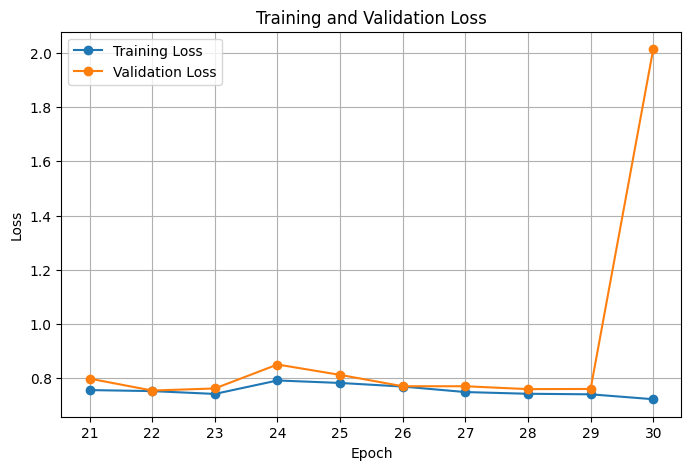

In [120]:
dl.train(10)

Device: cuda
Epoch: 31
Duration: 0 minutes and 21 seconds
Training Loss: 1.0843891501426697
Validation Loss: 0.9131631255149841
Epoch: 32
Duration: 0 minutes and 20 seconds
Training Loss: 0.8356192220341075
Validation Loss: 0.7982966303825378
Epoch: 33
Duration: 0 minutes and 21 seconds
Training Loss: 0.7781676216558977
Validation Loss: 0.8111268877983093
Epoch: 34
Duration: 0 minutes and 20 seconds
Training Loss: 0.7513486417857084
Validation Loss: 0.7648231387138367
Epoch: 35
Duration: 0 minutes and 20 seconds
Training Loss: 0.7423607327721335
Validation Loss: 0.7669573426246643
Epoch: 36
Duration: 0 minutes and 20 seconds
Training Loss: 0.727356878193942
Validation Loss: 0.7513896226882935
✅Best Model saved from epoch 36 with validation loss 0.7513896226882935
Epoch: 37
Duration: 0 minutes and 20 seconds
Training Loss: 0.714951444755901
Validation Loss: 0.7501955628395081
✅Best Model saved from epoch 37 with validation loss 0.7501955628395081
Epoch: 38
Duration: 0 minutes and 21 sec

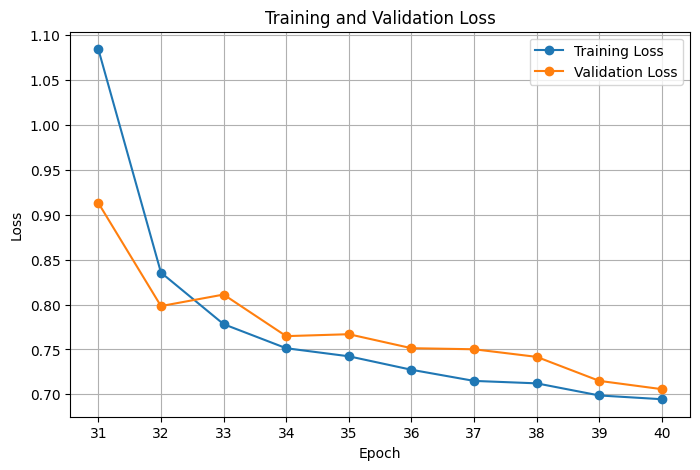

In [121]:
dl.train(10)

Device: cuda
Epoch: 41
Duration: 0 minutes and 20 seconds
Training Loss: 0.6958827864040028
Validation Loss: 0.7436864376068115
Epoch: 42
Duration: 0 minutes and 20 seconds
Training Loss: 0.6907954757863825
Validation Loss: 0.7148710489273071
Epoch: 43
Duration: 0 minutes and 20 seconds
Training Loss: 0.6981222196058794
Validation Loss: 0.7178162336349487
Epoch: 44
Duration: 0 minutes and 20 seconds
Training Loss: 0.6877700632268732
Validation Loss: 0.7725364565849304
Epoch: 45
Duration: 0 minutes and 20 seconds
Training Loss: 0.6778508208014749
Validation Loss: 0.6947798728942871
✅Best Model saved from epoch 45 with validation loss 0.6947798728942871
Epoch: 46
Duration: 0 minutes and 20 seconds
Training Loss: 0.6748707511208274
Validation Loss: 0.6978906393051147
Epoch: 47
Duration: 0 minutes and 20 seconds
Training Loss: 0.6625581112774935
Validation Loss: 0.694322943687439
✅Best Model saved from epoch 47 with validation loss 0.694322943687439
Epoch: 48
Duration: 0 minutes and 20 sec

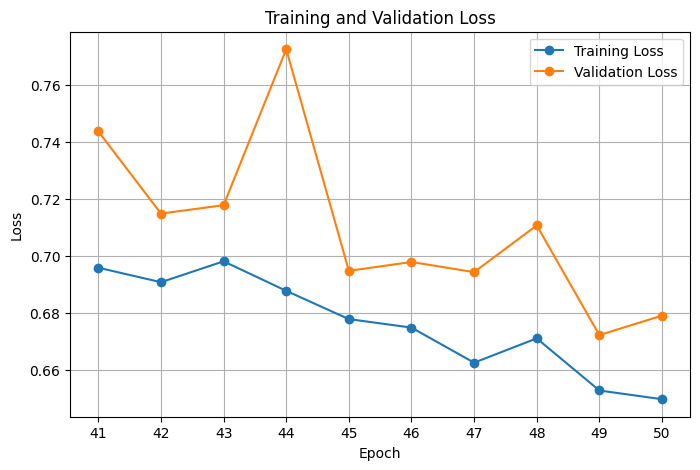

In [122]:
dl.train(10)

Device: cuda
Epoch: 51
Duration: 0 minutes and 20 seconds
Training Loss: 0.6552377614107999
Validation Loss: 0.6756167411804199
Epoch: 52
Duration: 0 minutes and 20 seconds
Training Loss: 0.6511840982870623
Validation Loss: 0.6749579906463623
Epoch: 53
Duration: 0 minutes and 20 seconds
Training Loss: 0.6396127072247592
Validation Loss: 0.6524379253387451
✅Best Model saved from epoch 53 with validation loss 0.6524379253387451
Epoch: 54
Duration: 0 minutes and 20 seconds
Training Loss: 0.632113061167977
Validation Loss: 0.6460539698600769
✅Best Model saved from epoch 54 with validation loss 0.6460539698600769
Epoch: 55
Duration: 0 minutes and 20 seconds
Training Loss: 0.6268697055903348
Validation Loss: 0.6274077296257019
✅Best Model saved from epoch 55 with validation loss 0.6274077296257019
Epoch: 56
Duration: 0 minutes and 20 seconds
Training Loss: 0.616248981519179
Validation Loss: 0.6517731547355652
Epoch: 57
Duration: 0 minutes and 20 seconds
Training Loss: 0.6250318830663507
Vali

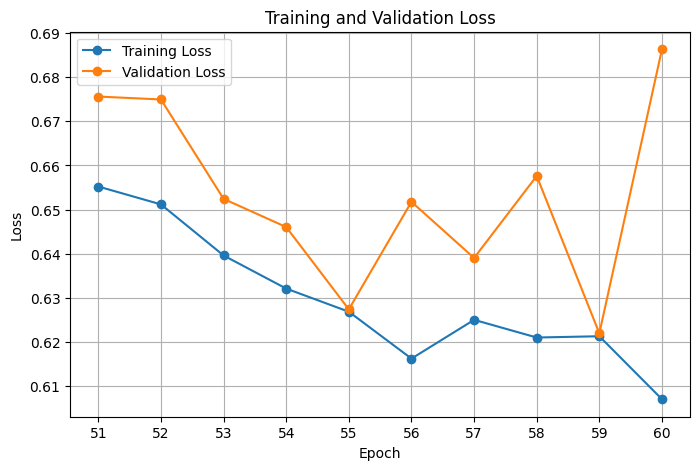

In [123]:
dl.train(10)

Device: cuda
Epoch: 61
Duration: 0 minutes and 20 seconds
Training Loss: 0.611474644054066
Validation Loss: 0.6309973001480103
Epoch: 62
Duration: 0 minutes and 20 seconds
Training Loss: 0.6020267497409474
Validation Loss: 0.6608977317810059
Epoch: 63
Duration: 0 minutes and 20 seconds
Training Loss: 0.609419356692921
Validation Loss: 0.6127365827560425
✅Best Model saved from epoch 63 with validation loss 0.6127365827560425
Epoch: 64
Duration: 0 minutes and 20 seconds
Training Loss: 0.5785351612351157
Validation Loss: 0.5975399613380432
✅Best Model saved from epoch 64 with validation loss 0.5975399613380432
Epoch: 65
Duration: 0 minutes and 20 seconds
Training Loss: 0.6100246960466559
Validation Loss: 0.6573975086212158
Epoch: 66
Duration: 0 minutes and 20 seconds
Training Loss: 0.6221084107052196
Validation Loss: 0.6388359665870667
Epoch: 67
Duration: 0 minutes and 20 seconds
Training Loss: 0.5995247580788352
Validation Loss: 0.605580747127533
Epoch: 68
Duration: 0 minutes and 20 seco

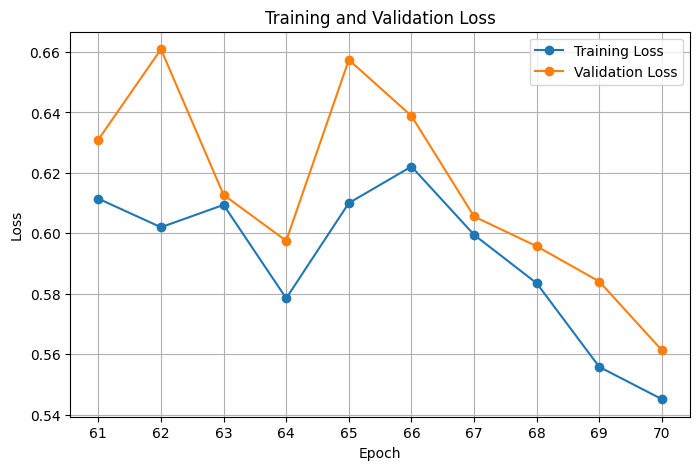

In [124]:
dl.train(10)

Device: cuda
Epoch: 71
Duration: 0 minutes and 20 seconds
Training Loss: 0.5235515616156838
Validation Loss: 0.6241727471351624
Epoch: 72
Duration: 0 minutes and 20 seconds
Training Loss: 0.5432027713818983
Validation Loss: 0.570055365562439
Epoch: 73
Duration: 0 minutes and 20 seconds
Training Loss: 0.5331390527161685
Validation Loss: 0.5683715343475342
Epoch: 74
Duration: 0 minutes and 20 seconds
Training Loss: 0.536914427172054
Validation Loss: 0.5543808937072754
✅Best Model saved from epoch 74 with validation loss 0.5543808937072754
Epoch: 75
Duration: 0 minutes and 20 seconds
Training Loss: 0.5355392450636084
Validation Loss: 0.6078407764434814
Epoch: 76
Duration: 0 minutes and 20 seconds
Training Loss: 0.5235884839838202
Validation Loss: 0.5406458377838135
✅Best Model saved from epoch 76 with validation loss 0.5406458377838135
Epoch: 77
Duration: 0 minutes and 20 seconds
Training Loss: 0.515483406457034
Validation Loss: 0.5909467935562134
Epoch: 78
Duration: 0 minutes and 20 seco

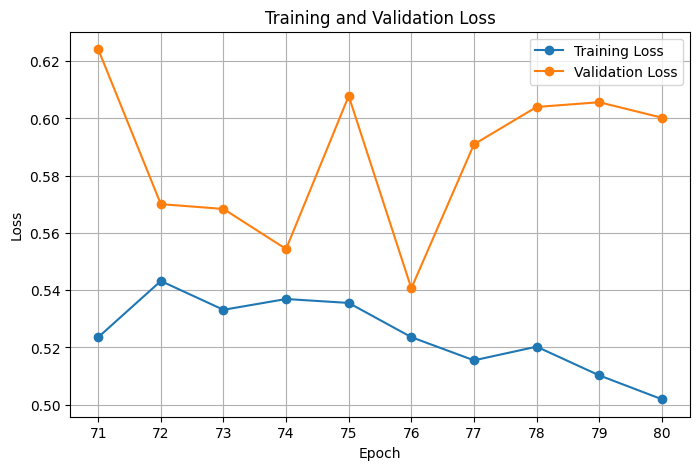

In [125]:
dl.train(10)

Device: cuda
Epoch: 81
Duration: 0 minutes and 20 seconds
Training Loss: 0.48927365920760413
Validation Loss: 0.5276685357093811
✅Best Model saved from epoch 81 with validation loss 0.5276685357093811
Epoch: 82
Duration: 0 minutes and 20 seconds
Training Loss: 0.46664229848168115
Validation Loss: 0.554966926574707
Epoch: 83
Duration: 0 minutes and 20 seconds
Training Loss: 0.4675795219161294
Validation Loss: 0.5265692472457886
✅Best Model saved from epoch 83 with validation loss 0.5265692472457886
Epoch: 84
Duration: 0 minutes and 20 seconds
Training Loss: 0.4501531151208011
Validation Loss: 0.4935862720012665
✅Best Model saved from epoch 84 with validation loss 0.4935862720012665
Epoch: 85
Duration: 0 minutes and 20 seconds
Training Loss: 0.4704508862712167
Validation Loss: 0.5207512378692627
Epoch: 86
Duration: 0 minutes and 20 seconds
Training Loss: 0.45110762932083825
Validation Loss: 0.5014988780021667
Epoch: 87
Duration: 0 minutes and 20 seconds
Training Loss: 0.4375147413123738


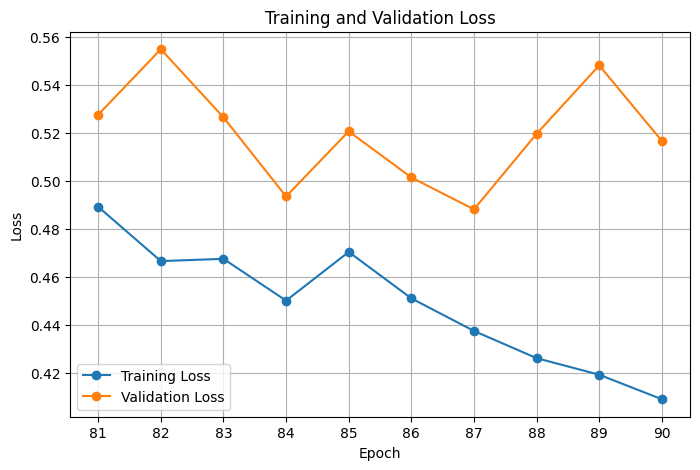

In [126]:
dl.train(10)

Device: cuda
Epoch: 91
Duration: 0 minutes and 20 seconds
Training Loss: 0.41891116987575183
Validation Loss: 0.5089967846870422
Epoch: 92
Duration: 0 minutes and 20 seconds
Training Loss: 0.4187644909728657
Validation Loss: 0.4938226640224457
Epoch: 93
Duration: 0 minutes and 20 seconds
Training Loss: 0.4080129319971258
Validation Loss: 0.5058170557022095
Epoch: 94
Duration: 0 minutes and 20 seconds
Training Loss: 0.4036211533979936
Validation Loss: 0.5203873515129089
Epoch: 95
Duration: 0 minutes and 21 seconds
Training Loss: 0.38997481898827985
Validation Loss: 0.49116167426109314
Epoch: 96
Duration: 0 minutes and 20 seconds
Training Loss: 0.39386815103617584
Validation Loss: 0.6020345687866211
Epoch: 97
Duration: 0 minutes and 20 seconds
Training Loss: 0.43127556280656293
Validation Loss: 0.48538675904273987
✅Best Model saved from epoch 97 with validation loss 0.48538675904273987
Epoch: 98
Duration: 0 minutes and 20 seconds
Training Loss: 0.4067288799719377
Validation Loss: 0.47936

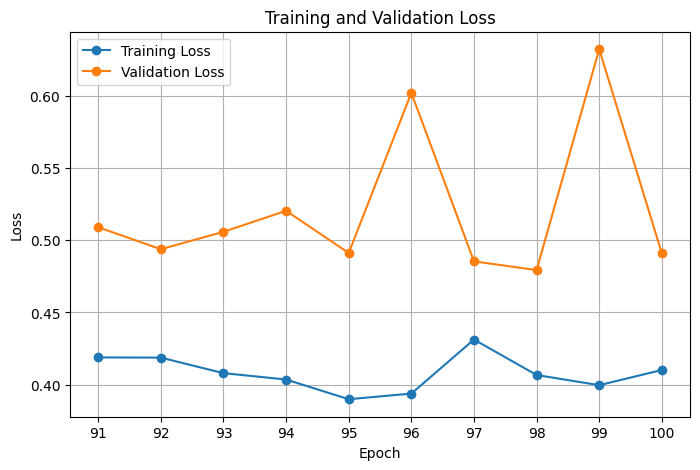

In [127]:
dl.train(10)

Device: cuda
Epoch: 101
Duration: 0 minutes and 20 seconds
Training Loss: 0.38202264363115485
Validation Loss: 0.5101351141929626
Epoch: 102
Duration: 0 minutes and 20 seconds
Training Loss: 0.3714701397852464
Validation Loss: 0.4994639754295349
Epoch: 103
Duration: 0 minutes and 20 seconds
Training Loss: 0.3599722547964616
Validation Loss: 0.46050697565078735
✅Best Model saved from epoch 103 with validation loss 0.46050697565078735
Epoch: 104
Duration: 0 minutes and 20 seconds
Training Loss: 0.3722300854596225
Validation Loss: 0.5209941864013672
Epoch: 105
Duration: 0 minutes and 20 seconds
Training Loss: 0.3992578468539498
Validation Loss: 0.5246051549911499
Epoch: 106
Duration: 0 minutes and 20 seconds
Training Loss: 0.3750304200432517
Validation Loss: 0.46903327107429504
Epoch: 107
Duration: 0 minutes and 20 seconds
Training Loss: 0.35980416427959094
Validation Loss: 0.4715323746204376
Epoch: 108
Duration: 0 minutes and 20 seconds
Training Loss: 0.34256777980110864
Validation Loss:

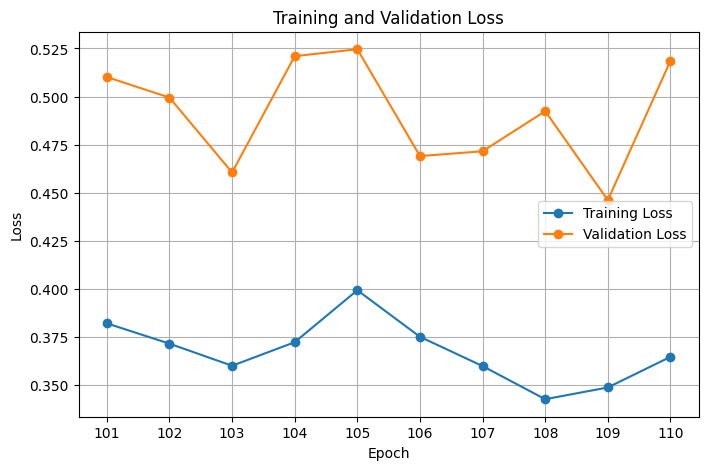

In [128]:
dl.train(10)

Device: cuda
Epoch: 111
Duration: 0 minutes and 20 seconds
Training Loss: 0.3529846722429449
Validation Loss: 0.47093215584754944
Epoch: 112
Duration: 0 minutes and 20 seconds
Training Loss: 0.33559139750220557
Validation Loss: 0.5058607459068298
Epoch: 113
Duration: 0 minutes and 20 seconds
Training Loss: 0.32360587878660724
Validation Loss: 0.4793476462364197
Epoch: 114
Duration: 0 minutes and 20 seconds
Training Loss: 0.31645677848295733
Validation Loss: 0.44041186571121216
✅Best Model saved from epoch 114 with validation loss 0.44041186571121216
Epoch: 115
Duration: 0 minutes and 20 seconds
Training Loss: 0.3104355172677474
Validation Loss: 0.4389427602291107
✅Best Model saved from epoch 115 with validation loss 0.4389427602291107
Epoch: 116
Duration: 0 minutes and 20 seconds
Training Loss: 0.3094043758782474
Validation Loss: 0.4249667227268219
✅Best Model saved from epoch 116 with validation loss 0.4249667227268219
Epoch: 117
Duration: 0 minutes and 20 seconds
Training Loss: 0.305

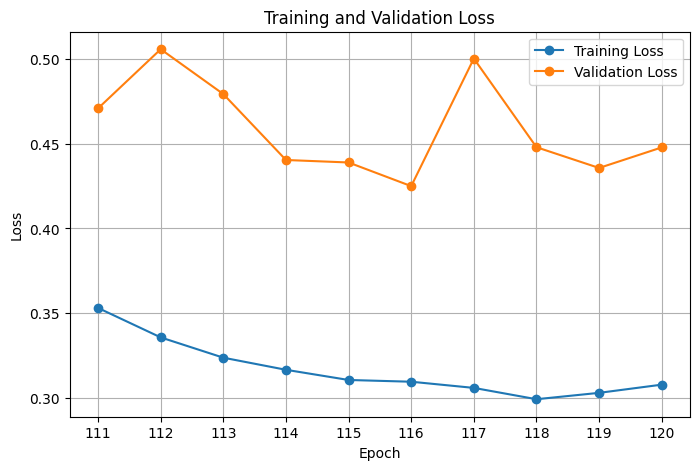

In [129]:
dl.train(10)

Device: cuda
Epoch: 121
Duration: 0 minutes and 20 seconds
Training Loss: 0.3354716897010803
Validation Loss: 0.4180072247982025
✅Best Model saved from epoch 121 with validation loss 0.4180072247982025
Epoch: 122
Duration: 0 minutes and 20 seconds
Training Loss: 0.3105531226504933
Validation Loss: 0.46120330691337585
Epoch: 123
Duration: 0 minutes and 20 seconds
Training Loss: 0.2992751625451175
Validation Loss: 0.4124448895454407
✅Best Model saved from epoch 123 with validation loss 0.4124448895454407
Epoch: 124
Duration: 0 minutes and 20 seconds
Training Loss: 0.2915440689433705
Validation Loss: 0.402832955121994
✅Best Model saved from epoch 124 with validation loss 0.402832955121994
Epoch: 125
Duration: 0 minutes and 20 seconds
Training Loss: 0.2793693027713082
Validation Loss: 0.43047818541526794
Epoch: 126
Duration: 0 minutes and 20 seconds
Training Loss: 0.2764349715276198
Validation Loss: 0.4375244975090027
Epoch: 127
Duration: 0 minutes and 20 seconds
Training Loss: 0.268342145

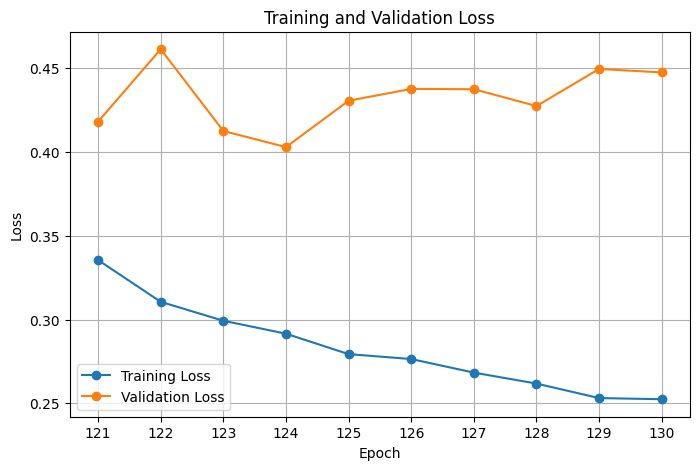

In [130]:
dl.train(10)

Device: cuda
Epoch: 131
Duration: 0 minutes and 20 seconds
Training Loss: 0.2515991005030545
Validation Loss: 0.4463288486003876
Epoch: 132
Duration: 0 minutes and 20 seconds
Training Loss: 0.24928219480948013
Validation Loss: 0.415346622467041
Epoch: 133
Duration: 0 minutes and 20 seconds
Training Loss: 0.24624972451816907
Validation Loss: 0.428360253572464
Epoch: 134
Duration: 0 minutes and 20 seconds
Training Loss: 0.23860332640734586
Validation Loss: 0.44342201948165894
Epoch: 135
Duration: 0 minutes and 20 seconds
Training Loss: 0.23530028624968094
Validation Loss: 0.4393206536769867
Epoch: 136
Duration: 0 minutes and 20 seconds
Training Loss: 0.2294174446301027
Validation Loss: 0.44661545753479004
Epoch: 137
Duration: 0 minutes and 20 seconds
Training Loss: 0.22801990671591324
Validation Loss: 0.44758906960487366
Epoch: 138
Duration: 0 minutes and 20 seconds
Training Loss: 0.2239918654615229
Validation Loss: 0.4641095995903015
Epoch: 139
Duration: 0 minutes and 20 seconds
Trainin

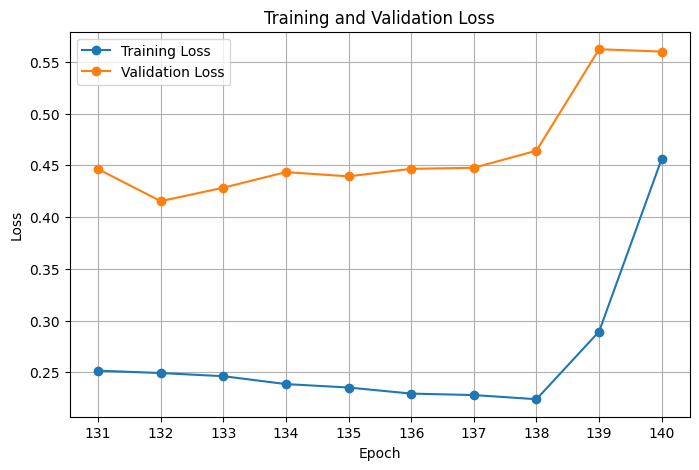

In [131]:
dl.train(10)

Device: cuda
Epoch: 141
Duration: 0 minutes and 20 seconds
Training Loss: 0.5285125428980048
Validation Loss: 0.5375517010688782
Epoch: 142
Duration: 0 minutes and 20 seconds
Training Loss: 0.44366477836262097
Validation Loss: 0.4951929748058319
Epoch: 143
Duration: 0 minutes and 20 seconds
Training Loss: 0.3796889592300762
Validation Loss: 0.48767486214637756
Epoch: 144
Duration: 0 minutes and 20 seconds
Training Loss: 0.3445863588289781
Validation Loss: 0.4902573525905609
Epoch: 145
Duration: 0 minutes and 20 seconds
Training Loss: 0.31841046430847864
Validation Loss: 0.5732449889183044
Epoch: 146
Duration: 0 minutes and 20 seconds
Training Loss: 0.3233788257295435
Validation Loss: 0.4231223165988922
Epoch: 147
Duration: 0 minutes and 20 seconds
Training Loss: 0.3130875256928531
Validation Loss: 0.44966191053390503
Epoch: 148
Duration: 0 minutes and 20 seconds
Training Loss: 0.32406435771421954
Validation Loss: 0.4415571093559265
Epoch: 149
Duration: 0 minutes and 20 seconds
Training

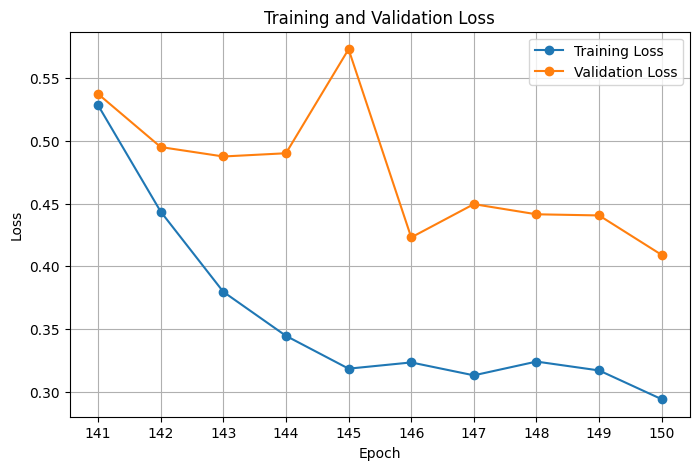

In [132]:
dl.train(10)

Device: cuda
Epoch: 151
Duration: 0 minutes and 20 seconds
Training Loss: 0.2713157602331855
Validation Loss: 0.4453502595424652
Epoch: 152
Duration: 0 minutes and 20 seconds
Training Loss: 0.26304821940985595
Validation Loss: 0.43847182393074036
Epoch: 153
Duration: 0 minutes and 20 seconds
Training Loss: 0.25820293345234613
Validation Loss: 0.4614649713039398
Epoch: 154
Duration: 0 minutes and 20 seconds
Training Loss: 0.24632223356853833
Validation Loss: 0.4387546181678772
Epoch: 155
Duration: 0 minutes and 20 seconds
Training Loss: 0.23431595889004794
Validation Loss: 0.4373018443584442
Epoch: 156
Duration: 0 minutes and 21 seconds
Training Loss: 0.227459348060868
Validation Loss: 0.4465683698654175
Epoch: 157
Duration: 0 minutes and 21 seconds
Training Loss: 0.22147909484126352
Validation Loss: 0.4374393820762634
Epoch: 158
Duration: 0 minutes and 20 seconds
Training Loss: 0.21550517732446844
Validation Loss: 0.4703967869281769
Epoch: 159
Duration: 0 minutes and 20 seconds
Trainin

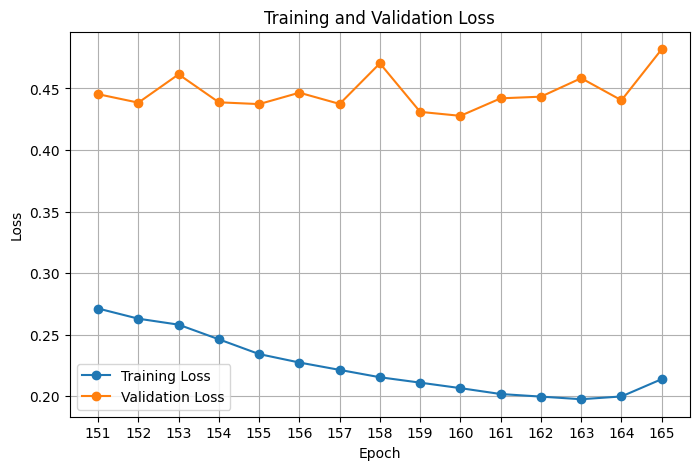

In [133]:
dl.train(15)

In [134]:
def plot_test_image_pred_mask_ground_truth_mask(test_image,pred_mask,ground_truth_mask):
    test_image = test_image.cpu()
    pred_mask = pred_mask[0].cpu()
    ground_truth_mask = ground_truth_mask[0].cpu()

    test_image = test_image.permute(1,2,0)
    mean = torch.tensor([0.485,0.456,0.406]).view(1,1,3)
    std = torch.tensor([0.229,0.224,0.225]).view(1,1,3)

    test_image = test_image * std + mean
    test_image = test_image.clamp(0,1)

    fig, axes = plt.subplots(1,3,figsize=(18,5))

    axes[0].imshow(test_image.numpy())
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(pred_mask.numpy())
    axes[1].set_title("Predicted Semantic Mask")
    axes[1].axis("off")

    axes[2].imshow(ground_truth_mask.numpy())
    axes[2].set_title("Ground Truth Semantic Mask")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()



In [135]:
def save_test_image_pred_mask_ground_truth_mask(test_image,pred_mask,ground_truth_mask,index):
    test_image = test_image.cpu()
    pred_mask = pred_mask[0].cpu()
    ground_truth_mask = ground_truth_mask[0].cpu()

    test_image = test_image.permute(1,2,0)
    mean = torch.tensor([0.485,0.456,0.406]).view(1,1,3)
    std = torch.tensor([0.229,0.224,0.225]).view(1,1,3)

    test_image = test_image * std + mean
    test_image = test_image.clamp(0,1)

    fig, axes = plt.subplots(1,3,figsize=(18,5))

    axes[0].imshow(test_image.numpy())
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(pred_mask.numpy())
    axes[1].set_title("Predicted Semantic Mask")
    axes[1].axis("off")

    axes[2].imshow(ground_truth_mask.numpy())
    axes[2].set_title("Ground Truth Semantic Mask")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig("Test Image "+str(index)+".png", dpi=150, bbox_inches="tight")
    plt.close()

In [136]:
dl.pick_the_best_model()
dl.model.eval()
for i in range(0,len(test_set)):
    print("Image:",i+1)
    im_test,msk_test = test_set[i]
    im_test = im_test.to(device)
    msk_test = msk_test.to(device)
    pred_mask = dl.model(im_test.unsqueeze(0))
    pred_mask = get_colored_predicted_mask(pred_mask)
    msk_test = get_colored_predicted_mask(msk_test.unsqueeze(0),predicted_mask=False)
    save_test_image_pred_mask_ground_truth_mask(im_test,pred_mask,msk_test,i+1)

Image: 1
Image: 2
Image: 3
Image: 4
Image: 5
Image: 6
Image: 7
Image: 8
Image: 9
Image: 10
Image: 11
Image: 12
Image: 13
Image: 14
Image: 15
Image: 16
Image: 17
Image: 18
Image: 19
Image: 20
Image: 21
Image: 22
Image: 23
Image: 24
Image: 25
Image: 26
Image: 27
Image: 28
